<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/Day4/Transfer_Learing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers ,models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
# 1) Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Class names (CIFAR-10)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
#Normalize
x_train=x_train.astype("float32")/225.0
x_test=x_test.astype("float32")/225.0

In [6]:
# Resize to 96x96 (MobileNetV2 needs larger input )
x_train=tf.image.resize(x_train,(96,96))
x_test=tf.image.resize(x_test,(96,96))

In [8]:
#Make labels 1D (shape:(N,))
y_train=y_train.squeeze()
y_test=y_test.squeeze()


In [11]:
# 2) Load pretrained MobileNetV2 (without top)
base_model=MobileNetV2(weights="imagenet", include_top=False,input_shape=(96,96,3))
base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
#3) Build model
model =models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [13]:
# 4) compile
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [16]:
# 5) Train
history=model.fit(
    x_train,y_train,
    validation_data=(x_test,y_test),
    epochs=2,
    batch_size=64
)

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 425s 544ms/step - accuracy: 0.8058 - loss: 0.5560 - val_accuracy: 0.8043 - val_loss: 0.5668
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 435s 557ms/step - accuracy: 0.8286 - loss: 0.4867 - val_accuracy: 0.8158 - val_loss: 0.5393


In [19]:
# 6) Predictions
probs=model.predict(x_test,batch_size=128)
y_pred=np.argmax(probs,axis=1)

#Overall accuracy (sklearn)
print("\n Sklearn Accuracy :",accuracy_score(y_test,y_pred))

79/79 ━━━━━━━━━━━━━━━━━━━━ 76s 967ms/step

 Sklearn Accuracy : 0.8158


In [20]:
#classification report (per class)
print("\n Classification Report :")
print(classification_report(y_test,y_pred,target_names=class_names))



 Classification Report :
              precision    recall  f1-score   support

    airplane       0.86      0.83      0.85      1000
  automobile       0.85      0.94      0.89      1000
        bird       0.71      0.81      0.76      1000
         cat       0.75      0.58      0.66      1000
        deer       0.81      0.74      0.77      1000
         dog       0.75      0.76      0.75      1000
        frog       0.86      0.85      0.85      1000
       horse       0.81      0.86      0.84      1000
        ship       0.88      0.88      0.88      1000
       truck       0.87      0.91      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



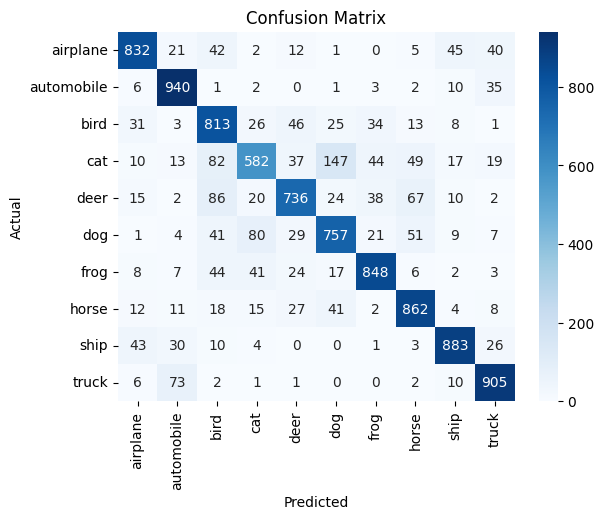

In [23]:
import seaborn as sns
#Confusion metircs
#Confusion matirx
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

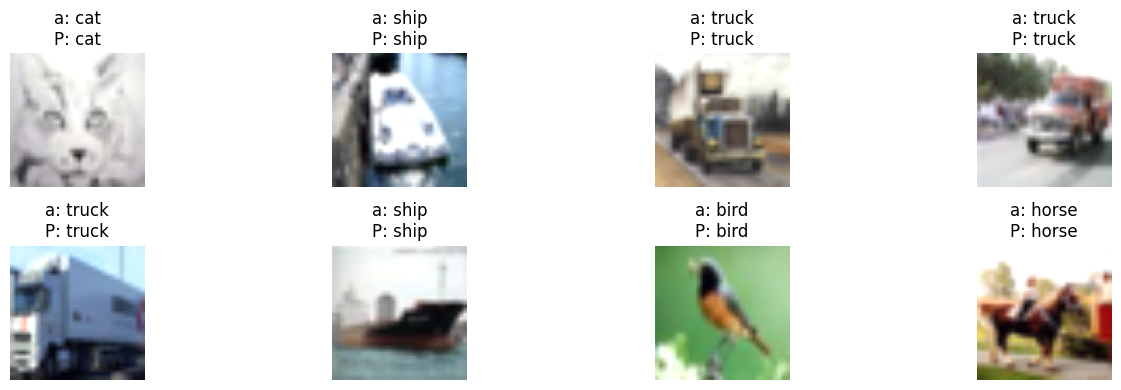

In [26]:
n = 8
idxs = np.random.choice(len(x_test), n, replace=False)


plt.figure(figsize=(14, 4))
for i, idx in enumerate(idxs):
    plt.subplot(2, 4, i+1)
    # x_test is a tensor; convert to numpy for plotting
    plt.imshow(x_test[idx].numpy())
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"a: {true_label}\nP: {pred_label}")
    plt.axis("off")


plt.tight_layout()
plt.show()




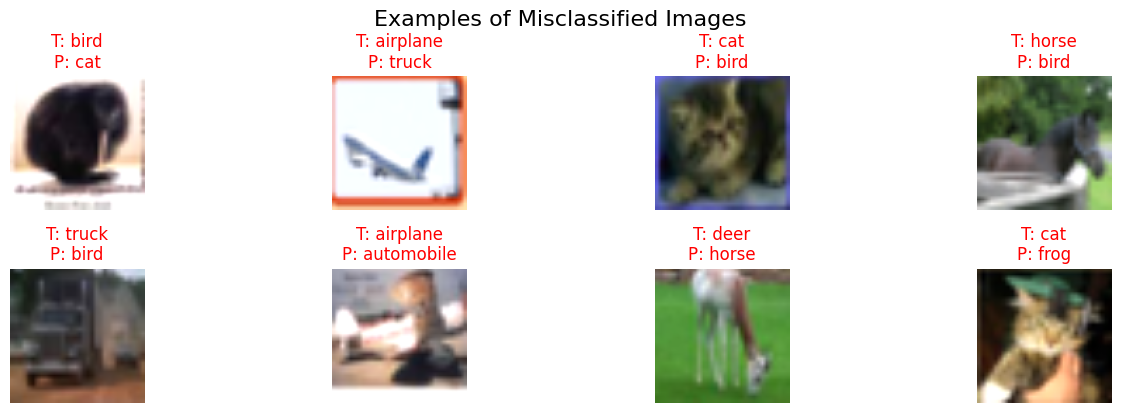

In [29]:
misclassified_indices = np.where(y_test != y_pred)[0]

# Display up to 8 misclassified images
n_display = min(len(misclassified_indices), 8)
sample_misclassified_indices = np.random.choice(misclassified_indices, n_display, replace=False)

plt.figure(figsize=(14, 4))
for i, idx in enumerate(sample_misclassified_indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx].numpy()) # Convert tensor to numpy for plotting
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"T: {true_label}\nP: {pred_label}", color=('red' if true_label != pred_label else 'black'))
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Examples of Misclassified Images", y=1.02, fontsize=16)
plt.show()